# 01.020 Design Thinking Project III

## Overview

The purpose of this project is to apply what you have learnt in this course. This includes working with data and visualizing it, creating machine learning model, as well as using metrics to measure the accuracy of your model.


## Deliverables

You need to submit this notebook along with the raw dataset.

## Students Submission

Student's Name:
- Jared Liw Zhi Long (1010278)
- Jerry Lim Jingjie (Lin Jingjie) (1010113)
- Michael Chua Leong Heng (1010563)
- Sathish Kumar S/O Kannan (1009927)
- Sun Yian (1010169)

## Context and Problem Statement

Describe your background, user persona, and problem statement here

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

## Dataset

- Describe your dataset.
- Put the link to the sources of your raw dataset.
- Put Python codes for loading the data into pandas dataframe(s). The data should be the raw data downloaded from the source. No pre-processing using any software (excel, python, etc) yet. Include this dataset in your submission.
- Explain each column of your dataset (can use comment or markdown).
- State which column is the dependent variable (target) and explain how it is related to your problem statement.
- State which columns are the independent variables (features) and describe your hypothesis on why these features can predict the target variable.

In [2]:
FILENAME: str = "Food_Security_data_E_All_Data_(Normalized).csv"
FEATURES_RAW: list[str] = [
    "Area Code",
    "Year",
    "Dietary energy supply used in the estimation of the prevalence of undernourishment (kcal/cap/day)",
    "Gross domestic product per capita, PPP, (constant 2021 international $)",
    "Per capita food supply variability (kcal/cap/day)",
    "Percentage of population using at least basic drinking water services (percent)",
    "Percentage of population using at least basic sanitation services (percent)",
    "Percentage of children under 5 years of age who are overweight (modelled estimates) (percent)",
    "Prevalence of obesity in the adult population (18 years and older) (percent)",
    "Prevalence of anemia among women of reproductive age (15-49 years) (percent)",
    "Minimum dietary energy requirement (kcal/cap/day)",
]
AREA_CODE: str = "AC"
YEAR: str = "YR"
FEATURES: list[str] = [AREA_CODE, YEAR, "DES", "GDP", "FSV", "DWS", "SAN", "OWC", "OBE", "ANM", "MDER"]
TARGET_RAW: str = "Prevalence of undernourishment (percent) (annual value)"
TARGET: str = "PoU"
SPLIT_YEAR: int = 2020

In [3]:
df = pd.read_csv(FILENAME)[["Area Code", "Item", "Year", "Value"]]
df = df[(df["Item"].isin([*FEATURES_RAW, TARGET_RAW])) & (df["Area Code"] >= 1000)]
df.head()

,Area Code,Item,Year,Value
212240,5000,Dietary energy supply used in the estimation o...,2000,2709
212241,5000,Dietary energy supply used in the estimation o...,2001,2705
212242,5000,Dietary energy supply used in the estimation o...,2002,2707
212243,5000,Dietary energy supply used in the estimation o...,2003,2713
212244,5000,Dietary energy supply used in the estimation o...,2004,2723


## Clean & Analyze your data

Use Python code to:
- Clean your data. If the dataset does not require cleaning, write code to validate the data instead (e.g., to ensure future data updates remain accurate and consistent).\
    *Data validation refers to the process of checking that data is accurate, complete, and consistent, and that it meets predefined rules or constraints (e.g., correct formats, correct types, valid ranges, and no missing or duplicate values).*
- Calculate Descriptive Statistics and other statistical analysis.
- Visualization with meaningful analysis description.

In [4]:
df_pivoted = df.pivot_table(
    index=["Area Code", "Year"],
    columns="Item",
    values="Value",
    aggfunc="first",
).reset_index().rename(columns=dict(zip([*FEATURES_RAW, TARGET_RAW], [*FEATURES, TARGET])))

df_pivoted

Item,AC,YR,DES,GDP,MDER,FSV,OWC,DWS,SAN,ANM,OBE,PoU
0,5000,2000,2709,12770,1801,10,5.3,82,56,29.3,8.7,12.8
1,5000,2001,2705,12905,1804,7,5.3,82,56,29,9,13
2,5000,2002,2707,13093,1807,8,5.4,82,57,28.8,9.3,13.2
3,5000,2003,2713,13403,1810,11,5.4,83,58,28.7,9.5,12.9
4,5000,2004,2723,13915,1813,13,5.4,83,60,28.5,9.8,12.7
...,...,...,...,...,...,...,...,...,...,...,...,...
1061,9011,2021,3243,19507,1867,10,8.3,NaN,NaN,19.3,15,2.8
1062,9011,2022,3278,20095,1871,11,8.4,NaN,NaN,19.6,15.5,2.7
1063,9011,2023,3300,20950,1873,18,8.5,NaN,NaN,20.1,16.1,2.7
1064,9011,2024,3287,21738,1876,22,8.6,NaN,NaN,NaN,16.7,2.6


In [5]:
df_pivoted.columns[df_pivoted.isna().any()]

Index(['DES', 'GDP', 'FSV', 'OWC', 'DWS', 'SAN', 'ANM', 'OBE', 'PoU'], dtype='str', name='Item')

In [6]:
pd.unique(df_pivoted.where(df_pivoted.apply(pd.to_numeric, errors="coerce").isna()).stack())

<ArrowStringArray>
[nan, '<2.5']
Length: 2, dtype: str

In [7]:
df_cleaned = df_pivoted.dropna().replace("<2.5", "0").astype(np.float64)

df_cleaned.describe()

Item,AC,YR,DES,GDP,MDER,FSV,OWC,DWS,SAN,ANM,OBE,PoU
count,691.000000,691.000000,691.000000,691.000000,691.000000,691.000000,691.000000,691.000000,691.000000,691.000000,691.000000,691.000000
mean,5300.424023,2011.568741,2883.036179,19778.681621,1818.509407,21.360347,6.828075,84.929088,71.296671,26.613893,17.550651,9.558321
std,186.917942,6.903631,409.576827,17273.306084,83.375027,21.275804,3.041490,16.298107,25.993594,11.304878,11.204716,8.370099
min,5000.000000,2000.000000,1977.000000,1813.000000,1655.000000,3.000000,1.600000,34.000000,14.000000,7.300000,2.500000,0.000000
25%,5203.000000,2006.000000,2565.000000,6135.000000,1763.000000,11.000000,4.800000,83.000000,51.500000,18.250000,7.850000,3.200000
50%,5303.000000,2012.000000,2891.000000,14331.000000,1819.000000,16.000000,6.600000,90.000000,80.000000,27.800000,17.000000,7.600000
75%,5401.000000,2018.000000,3144.000000,24283.000000,1863.500000,25.500000,8.500000,97.000000,93.500000,32.450000,24.050000,14.750000
max,5802.000000,2023.000000,3910.000000,72455.000000,1967.000000,228.000000,22.400000,100.000000,100.000000,52.900000,58.600000,38.000000


In [8]:
df_cleaned.dtypes

Item
AC      float64
YR      float64
DES     float64
GDP     float64
MDER    float64
FSV     float64
OWC     float64
DWS     float64
SAN     float64
ANM     float64
OBE     float64
PoU     float64
dtype: object

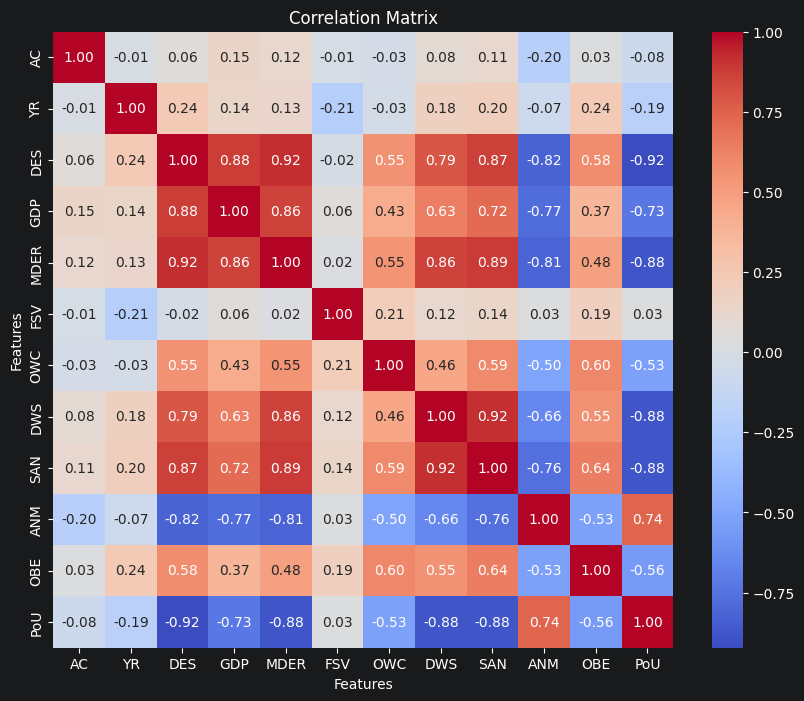

In [9]:
corr_matrix = df_cleaned.corr(numeric_only=True)

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, cmap="coolwarm", annot=True, fmt=".2f")
plt.title("Correlation Matrix")
plt.xlabel("Features")
plt.ylabel("Features");

In [10]:
corr_matrix

Item,AC,YR,DES,GDP,MDER,FSV,OWC,DWS,SAN,ANM,OBE,PoU
Item,,,,,,,,,,,,
AC,1.000000,-0.005197,0.060686,0.147166,0.121196,-0.010551,-0.026030,0.084801,0.113972,-0.204215,0.026999,-0.079285
YR,-0.005197,1.000000,0.241015,0.142012,0.133486,-0.209059,-0.030869,0.183328,0.198936,-0.070867,0.237392,-0.188857
DES,0.060686,0.241015,1.000000,0.875891,0.917827,-0.016918,0.551529,0.794758,0.868855,-0.819287,0.578529,-0.922289
GDP,0.147166,0.142012,0.875891,1.000000,0.864657,0.058704,0.425853,0.633364,0.719486,-0.773052,0.372306,-0.726615
MDER,0.121196,0.133486,0.917827,0.864657,1.000000,0.022680,0.545279,0.858225,0.886862,-0.813749,0.484458,-0.880808
FSV,-0.010551,-0.209059,-0.016918,0.058704,0.022680,1.000000,0.214032,0.120298,0.140113,0.026889,0.189104,0.028988
OWC,-0.026030,-0.030869,0.551529,0.425853,0.545279,0.214032,1.000000,0.456196,0.587978,-0.503548,0.596799,-0.531461
DWS,0.084801,0.183328,0.794758,0.633364,0.858225,0.120298,0.456196,1.000000,0.916161,-0.657134,0.554136,-0.882045
SAN,0.113972,0.198936,0.868855,0.719486,0.886862,0.140113,0.587978,0.916161,1.000000,-0.758050,0.642207,-0.878867


In [11]:
sorted_corr_target = corr_matrix[TARGET].sort_values(ascending=False, key=abs)

sorted_corr_target

Item
PoU     1.000000
DES    -0.922289
DWS    -0.882045
MDER   -0.880808
SAN    -0.878867
ANM     0.737258
GDP    -0.726615
OBE    -0.556262
OWC    -0.531461
YR     -0.188857
AC     -0.079285
FSV     0.028988
Name: PoU, dtype: float64

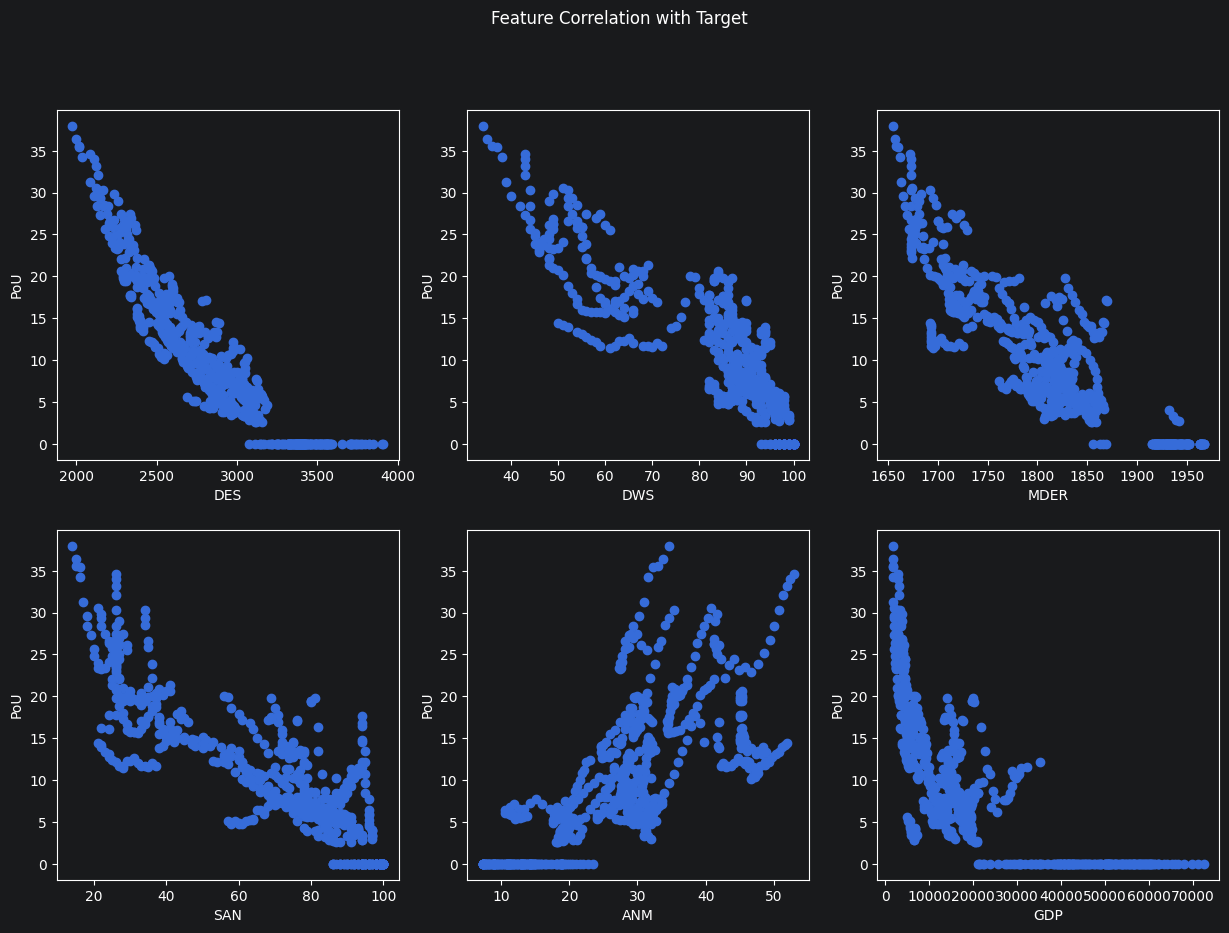

In [12]:
top6_cols = sorted_corr_target[1:7].index

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()
for i, col in enumerate(top6_cols):
    axes[i].scatter(df_cleaned[col], df_cleaned[TARGET])
    axes[i].set_xlabel(col)
    axes[i].set_ylabel(TARGET)
fig.suptitle("Feature Correlation with Target");

## Features and Target Preparation

Prepare features and target for model training.

In [13]:
class StandardScaler:
    def __init__(self):
        self.mean_ = None
        self.std_ = None
        self.features_ = None

    def fit(self, X):
        self.mean_ = X.mean()
        self.std_ = X.std()
        self.features_ = X.columns
        return self

    def _check(self, X):
        if self.mean_ is None or self.std_ is None:
            raise ValueError("Encoder has not been fitted.")
        if self.features_ is None or not self.features_.equals(X.columns):
            raise ValueError("Columns does not match fitted data.")

    def transform(self, X):
        self._check(X)
        X = X.copy()
        return (X - self.mean_) / self.std_

    def fit_transform(self, X):
        return self.fit(X).transform(X)

    def inverse_transform(self, X):
        self._check(X)
        X = X.copy()
        return X * self.std_ + self.mean_

In [14]:
df_train, df_test = df_cleaned[df_cleaned[YEAR] < SPLIT_YEAR], df_cleaned[df_cleaned[YEAR] >= SPLIT_YEAR]

df_train.shape, df_test.shape

((575, 12), (116, 12))

In [15]:
df_train.columns

Index(['AC', 'YR', 'DES', 'GDP', 'MDER', 'FSV', 'OWC', 'DWS', 'SAN', 'ANM',
       'OBE', 'PoU'],
      dtype='str', name='Item')

In [16]:
ss = StandardScaler()
df_train[FEATURES] = ss.fit_transform(df_train[FEATURES])
df_test[FEATURES] = ss.transform(df_test[FEATURES])

df_train.describe()

Item,AC,YR,DES,GDP,MDER,FSV,OWC,DWS,SAN,ANM,OBE,PoU
count,5.750000e+02,5.750000e+02,5.750000e+02,5.750000e+02,5.750000e+02,5.750000e+02,5.750000e+02,5.750000e+02,5.750000e+02,5.750000e+02,5.750000e+02,575.000000
mean,1.532301e-15,1.547052e-14,-1.853590e-16,-2.471453e-17,8.897231e-16,2.471453e-17,1.637338e-16,3.954325e-16,2.471453e-17,1.730017e-16,-2.471453e-16,9.718957
std,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,8.429385
min,-1.606924e+00,-1.662928e+00,-2.153305e+00,-1.031903e+00,-1.892885e+00,-8.442722e-01,-1.800014e+00,-3.002410e+00,-2.126337e+00,-1.675740e+00,-1.303466e+00,0.000000
25%,-5.216169e-01,-7.936701e-01,-7.786603e-01,-7.810666e-01,-6.609331e-01,-4.955560e-01,-7.016438e-01,-6.617599e-02,-8.320105e-01,-7.234519e-01,-9.072797e-01,3.500000
50%,1.301718e-02,7.558763e-02,-7.637446e-03,-3.032721e-01,5.146161e-03,-2.776084e-01,-8.381043e-02,2.933628e-01,3.100426e-01,1.070828e-01,-1.927669e-02,7.600000
75%,5.369586e-01,9.448453e-01,6.387510e-01,2.408993e-01,5.238628e-01,2.454659e-01,5.683470e-01,7.128248e-01,8.620349e-01,5.245243e-01,5.681715e-01,14.950000
max,2.680841e+00,1.640252e+00,2.350642e+00,2.896953e+00,1.761709e+00,8.963371e+00,4.000754e+00,9.525174e-01,1.147548e+00,2.289954e+00,3.605597e+00,38.000000


## Building Model

Use python code to build your model. Give explanation on this process.


**Note: You are NOT allowed to use scikit-learn or any other library to build the machine learning model. You can only use linear regression or logistic regression model you learnt from DDW course.**

In [17]:
class LinearRegression:
    def __init__(self, lr=0.001, n_iters=5000):
        self.lr_ = lr
        self.n_iters_ = n_iters
        self.weights_ = None
        self.history_ = []

    def _predict(self, X):
        return (X @ self.weights_).squeeze()

    def predict(self, X):
        X = np.hstack((np.ones((X.shape[0], 1), dtype=X.dtype), X))
        return self._predict(X)

    def _cost(self, X, y):
        n_samples, n_features = X.shape
        y_hat = self._predict(X)
        return (1 / (2 * n_samples)) * np.sum((y_hat - y) ** 2)

    def _cost_grad(self, X, y):
        n_samples, n_features = X.shape
        y_hat = self._predict(X)
        return (1 / n_samples) * X.T @ (y_hat - y)

    def fit(self, X, y):
        X = np.hstack((np.ones((X.shape[0], 1), dtype=X.dtype), X))

        n_samples, n_features = X.shape
        self.weights_ = np.zeros((n_features,))
        self.history_ = []

        for _ in range(self.n_iters_):
            self.weights_ -= self.lr_ * self._cost_grad(X, y)

            cost = self._cost(X, y)
            self.history_.append(cost)

        return self

In [18]:
X_train, y_train = df_train[FEATURES].to_numpy(), df_train[TARGET].to_numpy()
X_test, y_test = df_test[FEATURES].to_numpy(), df_test[TARGET].to_numpy()

In [19]:
lr = LinearRegression(n_iters=10000)
lr.fit(X_train, y_train);

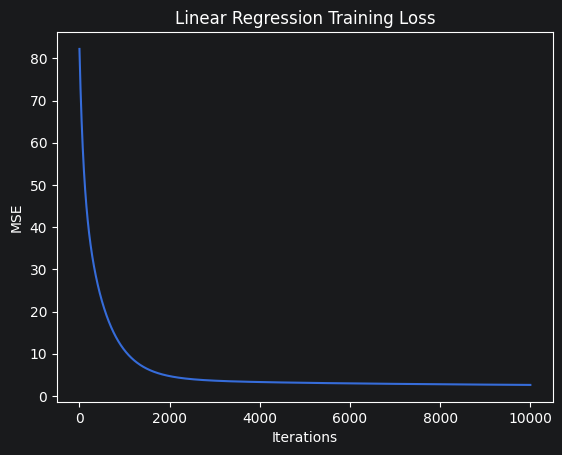

In [20]:
sns.lineplot(lr.history_)
plt.xlabel("Iterations")
plt.ylabel("MSE")
plt.title("Linear Regression Training Loss");

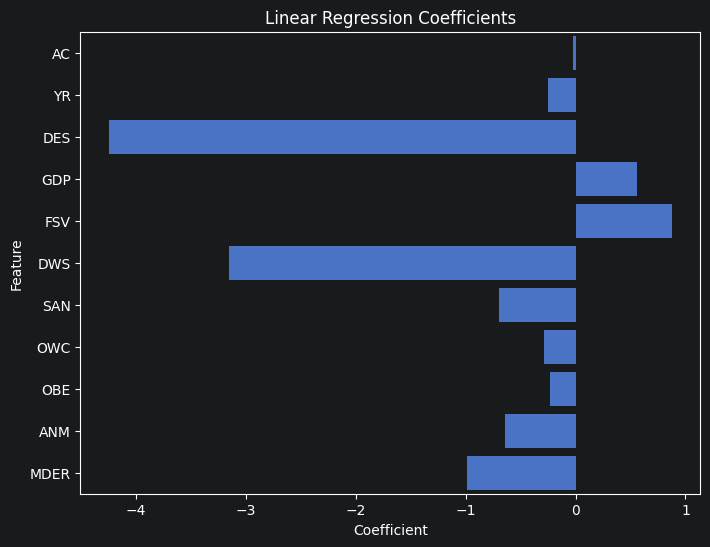

In [21]:
feature_weight_pairs = list(zip(FEATURES, lr.weights_.tolist()[1:]))
coef_df = pd.DataFrame(feature_weight_pairs, columns=["Feature", "Weight"])

plt.figure(figsize=(8, 6))
sns.barplot(data=coef_df, x="Weight", y="Feature")
plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.title(f"Linear Regression Coefficients");

## Evaluating the Model

- Describe the metrics of your choice.
- Evaluate your model performance.

In [22]:
def r2_score(y_true, y_pred):
    return float(1 - np.sum((y_true - y_pred) ** 2) / np.sum((y_true - np.mean(y_true, axis=0)) ** 2))

In [23]:
def root_mean_squared_error(y_true, y_pred):
    return float(np.mean((y_true - y_pred) ** 2).tolist() ** 0.5)

In [24]:
y_pred = lr.predict(X_test)

In [25]:
r2_score(y_test, y_pred), root_mean_squared_error(y_test, y_pred)

(0.8010974943074805, 3.578127936605367)

## Improving the Model

- Improve the models by performing data processing techniques or hyperparameter tuning.
- You can repeat the steps above to show the improvement as compared to the previous performance.

*Note: changing or adding more dataset is not allowed.*

In [26]:
class LinearRegressionLayer:
    def __init__(self, n_in, n_out, random_state=None):
        self.learnable_ = True
        self.random_state = random_state
        self.input_ = None
        self.weights_gradient_ = None
        rng = np.random.default_rng(random_state)
        self.weights_ = rng.standard_normal((n_out, n_in + 1)) * np.sqrt(2 / n_in)

    def forward(self, X):
        X = np.hstack((np.ones((X.shape[0], 1), dtype=X.dtype), X))
        self.input_ = X  # (n_samples, n_in + 1)
        return X @ self.weights_.T  # (n_samples, n_out)

    def backward(self, delta):  # (n_samples, n_out)
        self.weights_gradient_ = delta.T @ self.input_  # (n_out, n_in + 1)
        # Differentiate bias terms get 0
        return delta @ self.weights_[:, 1:]  # (n_samples, n_in)

In [27]:
class Relu:
    def __init__(self):
        self.learnable_ = False
        self.input_ = None

    def forward(self, X):  # (n_samples, n_in)
        self.input_ = X
        return np.maximum(0, X)

    def backward(self, delta):  # (n_samples, n_out)
        delta_relu = self.input_ > 0  # (n_samples, n_in)
        return delta * delta_relu  # Element-wise, n_in == n_out

In [28]:
class RegressiveMultilayerPerceptron:
    def __init__(self, layers, lr=0.001, n_iters=5000):
        self.lr_ = lr
        self.n_iters_ = n_iters
        self.layers_ = layers
        self.history_ = []

    def predict(self, X):
        cur = X
        for layer in self.layers_:
            cur = layer.forward(cur)
        return cur.squeeze(-1)  # (n_samples,)

    def _cost(self, X, y):  # Same as single layer
        n_samples, _ = X.shape
        y_hat = self.predict(X)
        return (1 / (2 * n_samples)) * np.sum((y_hat - y) ** 2)

    def _cost_grad_wrt_pred(self, X, y):
        n_samples, _ = X.shape
        y_hat = self.predict(X)
        return np.expand_dims((y_hat - y) / n_samples, axis=-1)  # (n_samples, 1)

    def _backpropagate(self, X, y):
        delta = self._cost_grad_wrt_pred(X, y)

        for layer in self.layers_[::-1]:
            delta = layer.backward(delta)
            if layer.learnable_:
                layer.weights_ -= self.lr_ * layer.weights_gradient_

    def fit(self, X, y):
        self.history_ = []

        for _ in range(self.n_iters_):
            self._backpropagate(X, y)

            cost = self._cost(X, y)
            self.history_.append(cost)

In [29]:
mlp = RegressiveMultilayerPerceptron([
    LinearRegressionLayer(X_train.shape[1], 32, random_state=42),
    Relu(),
    LinearRegressionLayer(32, 16, random_state=42),
    Relu(),
    LinearRegressionLayer(16, 1, random_state=42),
], lr=0.001, n_iters=5000)
mlp.fit(X_train, y_train)

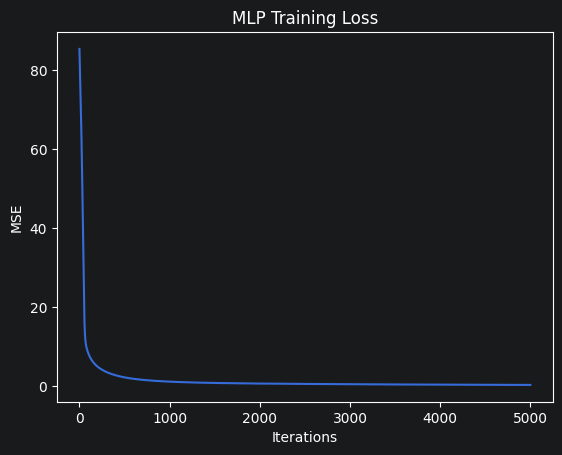

In [30]:
sns.lineplot(mlp.history_)
plt.xlabel("Iterations")
plt.ylabel("MSE")
plt.title("MLP Training Loss");

In [31]:
y_pred_mlp = mlp.predict(X_test)

r2_score(y_test, y_pred_mlp), root_mean_squared_error(y_test, y_pred_mlp)

(0.9531063210919761, 1.7373722894554198)

## Discussion and Analysis

- Analyze the results of your metrics.
- Explain how does your analysis and machine learning help to solve your problem statement.
- Conclusion.